
  Random Forest
  ROC-AUC : 0.9810
  Threshold: 0.4
              precision    recall  f1-score   support

 No Diabetes       1.00      0.84      0.91       363
    Diabetes       0.77      0.99      0.87       191

    accuracy                           0.90       554
   macro avg       0.88      0.92      0.89       554
weighted avg       0.92      0.90      0.90       554



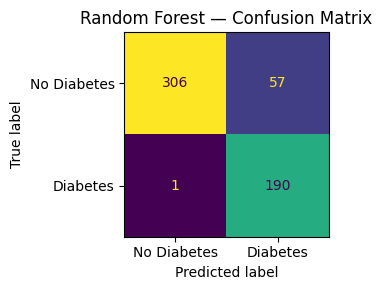

C:\Users\abdul\anaconda3\envs\ocr\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:02:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  XGBoost
  ROC-AUC : 0.9896
  Threshold: 0.4
              precision    recall  f1-score   support

 No Diabetes       0.99      0.91      0.95       363
    Diabetes       0.85      0.97      0.91       191

    accuracy                           0.93       554
   macro avg       0.92      0.94      0.93       554
weighted avg       0.94      0.93      0.93       554



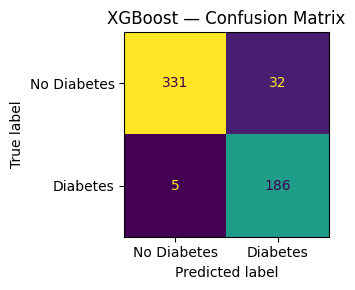


  MLP
  ROC-AUC : 0.9298
  Threshold: 0.4
              precision    recall  f1-score   support

 No Diabetes       0.95      0.78      0.86       363
    Diabetes       0.69      0.92      0.79       191

    accuracy                           0.83       554
   macro avg       0.82      0.85      0.82       554
weighted avg       0.86      0.83      0.83       554



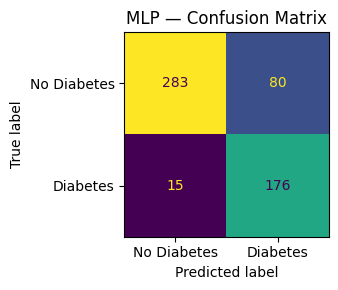

C:\Users\abdul\anaconda3\envs\ocr\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:02:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  Soft Ensemble
  ROC-AUC : 0.9824
  Threshold: 0.4
              precision    recall  f1-score   support

 No Diabetes       0.98      0.85      0.91       363
    Diabetes       0.77      0.97      0.86       191

    accuracy                           0.89       554
   macro avg       0.88      0.91      0.89       554
weighted avg       0.91      0.89      0.89       554



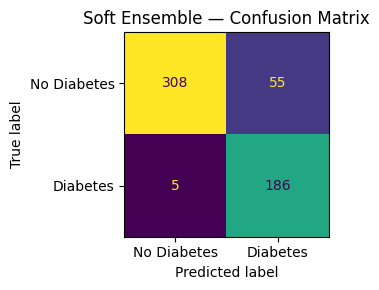

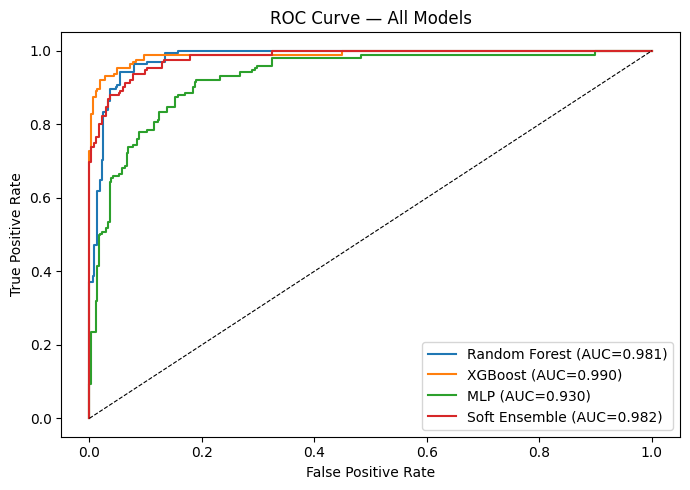


🏆 Best model: XGB — AUC: 0.9896
   Saved to: C:\Users\abdul\Amr senior\dataset\best_model_xgb.pkl


In [2]:
import numpy as np
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

base = r"C:\Users\abdul\Amr senior\dataset"

# ── Load processed data ──────────────────────────────────────────
X_train = np.load(f"{base}\\X_train.npy")
X_test  = np.load(f"{base}\\X_test.npy")
y_train = np.load(f"{base}\\y_train.npy")
y_test  = np.load(f"{base}\\y_test.npy")

# ── Define models ────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced'
)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

# ── Soft Voting Ensemble ─────────────────────────────────────────
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('mlp', mlp)],
    voting='soft'
)

# ── Train & Evaluate function ────────────────────────────────────
def evaluate(name, model, X_tr, y_tr, X_te, y_te, threshold=0.40):
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)[:, 1]
    preds = (proba >= threshold).astype(int)

    auc = roc_auc_score(y_te, proba)
    report = classification_report(y_te, preds, target_names=['No Diabetes','Diabetes'])
    cm = confusion_matrix(y_te, preds)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  ROC-AUC : {auc:.4f}")
    print(f"  Threshold: {threshold}")
    print(report)

    # Confusion matrix plot
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=['No Diabetes','Diabetes']).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{base}\\cm_{name.replace(' ','_')}.png", dpi=120)
    plt.show()

    return model, auc

# ── Run all ──────────────────────────────────────────────────────
rf_model,  auc_rf  = evaluate("Random Forest", rf,       X_train, y_train, X_test, y_test)
xgb_model, auc_xgb = evaluate("XGBoost",       xgb,      X_train, y_train, X_test, y_test)
mlp_model, auc_mlp = evaluate("MLP",           mlp,      X_train, y_train, X_test, y_test)
ens_model, auc_ens = evaluate("Soft Ensemble", ensemble, X_train, y_train, X_test, y_test)

# ── ROC Curve comparison ─────────────────────────────────────────
plt.figure(figsize=(7, 5))
for name, model, auc in [
    ("Random Forest", rf_model,  auc_rf),
    ("XGBoost",       xgb_model, auc_xgb),
    ("MLP",           mlp_model, auc_mlp),
    ("Soft Ensemble", ens_model, auc_ens),
]:
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--', linewidth=0.8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — All Models")
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"{base}\\roc_all_models.png", dpi=120)
plt.show()

# ── Save best model ──────────────────────────────────────────────
best_model = max(
    [("rf", rf_model, auc_rf), ("xgb", xgb_model, auc_xgb),
     ("mlp", mlp_model, auc_mlp), ("ensemble", ens_model, auc_ens)],
    key=lambda x: x[2]
)
joblib.dump(best_model[1], f"{base}\\best_model_{best_model[0]}.pkl")
print(f"\n🏆 Best model: {best_model[0].upper()} — AUC: {best_model[2]:.4f}")
print(f"   Saved to: {base}\\best_model_{best_model[0]}.pkl")

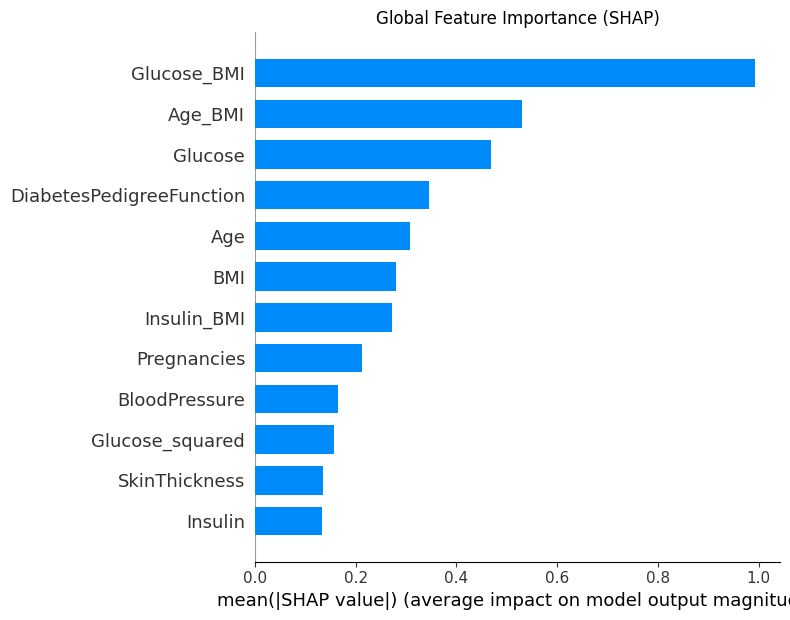

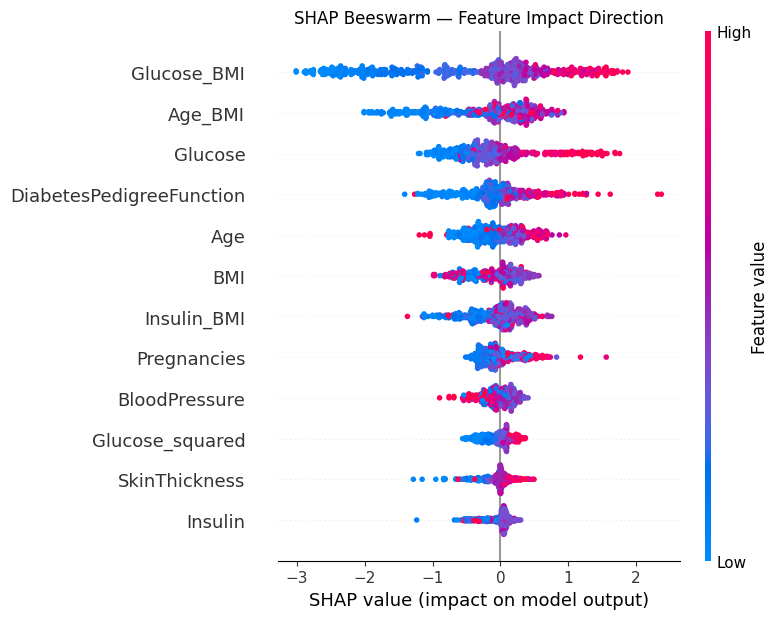


Patient #0 — Diabetes probability: 3.2%


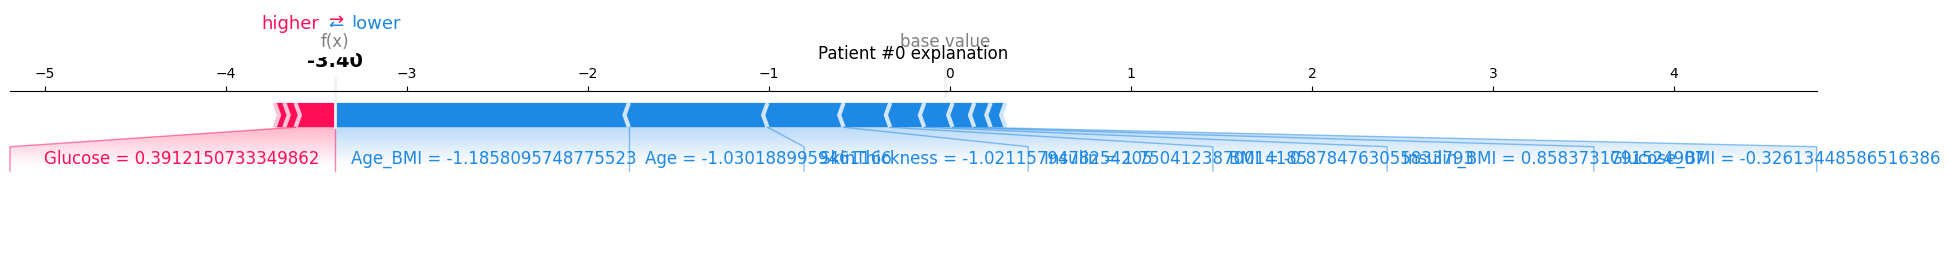


✅ SHAP plots saved!


In [4]:
import shap
import joblib
import numpy as np
import matplotlib.pyplot as plt

base = r"C:\Users\abdul\Amr senior\dataset"

# Load model and test data
xgb_model = joblib.load(f"{base}\\best_model_xgb.pkl")
X_test    = np.load(f"{base}\\X_test.npy")
y_test    = np.load(f"{base}\\y_test.npy")

feature_names = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age',
    'Glucose_BMI', 'Age_BMI', 'Glucose_squared', 'Insulin_BMI'
]

# ── SHAP values ──────────────────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# ── Plot 1: Global feature importance ───────────────────────────
plt.figure()
shap.summary_plot(
    shap_values, X_test,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig(f"{base}\\shap_importance.png", dpi=120)
plt.show()

# ── Plot 2: Beeswarm (impact direction) ─────────────────────────
plt.figure()
shap.summary_plot(
    shap_values, X_test,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP Beeswarm — Feature Impact Direction")
plt.tight_layout()
plt.savefig(f"{base}\\shap_beeswarm.png", dpi=120)
plt.show()

# ── Plot 3: Single patient explanation ──────────────────────────
patient_idx = 0   # change to any patient index you want
proba = xgb_model.predict_proba(X_test)[patient_idx][1]
print(f"\nPatient #{patient_idx} — Diabetes probability: {proba:.1%}")

shap.force_plot(
    explainer.expected_value,
    shap_values[patient_idx],
    X_test[patient_idx],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.title(f"Patient #{patient_idx} explanation")
plt.tight_layout()
plt.savefig(f"{base}\\shap_patient_{patient_idx}.png", dpi=120, bbox_inches='tight')
plt.show()

print("\n✅ SHAP plots saved!")